# Cosmology with GWs/FRBs Associations (without redshift information)

Based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, ticker

import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import z_at_value
import astropy.constants as astc
from astropy.cosmology import Planck18

import scipy.constants as const
from scipy.integrate import quad
from scipy.stats import gaussian_kde

In [2]:
print(Planck18)

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)


In [3]:
### Defining useful constants (SI)

OMEGA_MATTER = 0.2865
HUBBLE = 69.3

f_IGM = 0.83
OMEGA_BARYONS = 0.049
PI = const.pi
C_LIGHT = const.c
G_NEWTON = const.G
M_PROTON = const.m_p

KM_2_MPC = 3.24e-20 
HUBBLE_TIME = HUBBLE*KM_2_MPC

We are defining the IGM dispersion measure (DM), based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ and we have assumed a flar universe with $w=-1$ (for DE).

In [4]:
def dDM_integrand(z, Om):
    """
    Function that it inside the integral of the DM formula.
    
    Input
    ----------
    z : redshift
    Om: Omega matter
    """
    return (1+z)/np.sqrt(Om*(1+z)**3+1-Om)

def dispersion_measure(z, Om, H0):

    factor = 3*C_LIGHT*(H0*KM_2_MPC)*OMEGA_BARYONS*f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand, 0, z, args=(Om))[0]
    
    unit_transform = 3.24e-23
    
    DM = unit_transform*factor*integral
    
    return DM

## Ideal luminosity distances (proof of concept)

When we do not have redshift information, we can use $d_L$ (luminosity distance) from GWs and ${\rm DM}_{\rm IGM}$ from the FRBs to put constraints on the cosmological parameters ($H_0, \Omega_m$).

In this simplified case, we assume idealised $d_L$, i.e. precise determination of distances. Then, we can calculate:

$$
d_L^{\rm obs}\quad \underrightarrow{(H_0, \Omega_m)}\quad z \quad \underrightarrow{(H_0, \Omega_m)}\quad {\rm DM},
$$

which can then be compared to ${\rm DM}^{\rm obs}$, with the standard $\chi^2$ statistic


$$
\chi^2 (H_0, \Omega_m) = \frac{[{\rm DM}^{\rm obs}-{\rm DM}(H_0, \Omega_m)]^2}{\sigma_{{\rm DM}}^2},
$$

where for $\sigma_{{\rm DM}}$ we assume a value of $\sigma_{{\rm DM}} \sim 105$ pc/cm$^3$.

#### **Creation of mock events** (very simplified)

We draw some random distances from $[L_{\min}, L_{\max}]$, from them we find redshifts, based on the fiducial cosmology $(H^f_0, \Omega_m^f)$. With the redshifts we calculate the mock $DM$, following $DM^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f), \sigma_{\rm DM})$.

With these we calculate the $\chi^2$ statistic and constrain cosmology.

In [5]:
## Distances range
dL_range = np.linspace(1000, 20000, 100)

## Choose N random distances, i.e. random events, from the distance range
d_luminosity = np.random.choice(dL_range, size=15, replace=False)
d_luminosity = np.sort(d_luminosity)  # Just to simplify plotting - not affecting anything else

## Calculate redshifts for these distances based on fiducial cosmology
cosmo_fid = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)
redshifts = z_at_value(cosmo_fid.luminosity_distance, d_luminosity*u.Mpc,method='bounded').value

In [6]:
DM_theory = []
DM_obs = []

sigma_DM = 105

for z_val in redshifts:
    DM = dispersion_measure(z_val, OMEGA_MATTER, HUBBLE)
    DM_theory.append(DM)
    DM_obs.append(np.random.normal(DM, sigma_DM))    

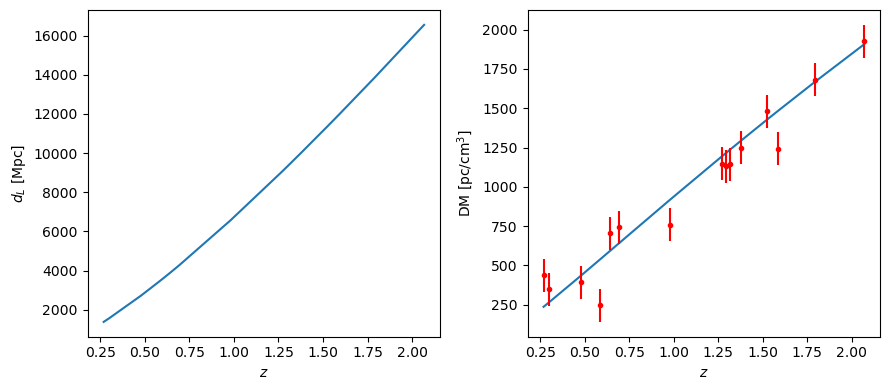

In [7]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(redshifts, d_luminosity)
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')

ax2.plot(redshifts, DM_theory)
ax2.errorbar(redshifts, DM_obs, yerr=sigma_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

**Cosmological inference**

Considering the cases of $\Omega_m$ fixed or not.

In [8]:
H0_array = np.linspace(10, 140, 140)
Omega_m_array = np.linspace(0.1, 0.5, 100)

H_, Om_ = np.meshgrid(H0_array, Omega_m_array)

In [9]:
### Fitting only H0

chi_fit = []

for idx, H0 in enumerate(H0_array):
    log_chi=0
    for idx_z, z_val in enumerate(redshifts):
        DM = dispersion_measure(z_val, OMEGA_MATTER, H0)
        
        log_chi += (DM_obs[idx_z]-DM)**2/sigma_DM**2  # For all events, add in χ^2
    
    chi_fit.append(log_chi)
    
chi_fit = np.array(chi_fit)    

In [10]:
### Fitting H0 & Om

chi_fit_2D = np.zeros_like(H_)

for idx_H, H0 in enumerate(H0_array):
    for idx_Om, Om in enumerate(Omega_m_array):
        log_chi=0
        for idx_z, z_val in enumerate(redshifts):
            DM = dispersion_measure(z_val, Om, H0)
        
            log_chi += (DM_obs[idx_z]-DM)**2/sigma_DM**2
    
        chi_fit_2D[idx_Om, idx_H] = log_chi

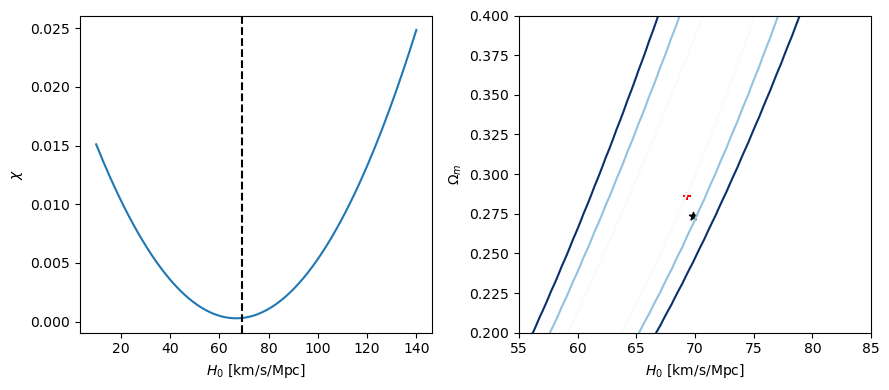

In [11]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(H0_array, chi_fit/np.sum(chi_fit))
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_ylabel(r'$\chi$')


### NOTE: Contours to be checked
chi_2D_min = np.min(chi_fit_2D)
ax2.contour(H_, Om_, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax2.scatter(H0_array[64], Omega_m_array[43], marker='*', c='black')
ax2.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r')
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax2.set_ylabel(r'$\Omega_m$')
ax2.set_xlim(55, 85)
ax2.set_ylim(0.2, 0.4)

plt.tight_layout()
plt.show()

# Distances with errors

Now take into account that distances can have errors - for a range of redshifts calculate the posteriors and marginalise over redshift:

$$
\int dz \ P\left(d_L^{\rm obs}|d_L(z, H_0, \Omega_m)\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, H_0, \Omega_m)\right)
$$

<div class="alert alert-block alert-danger">
<b>NB:</b> Extra things to consider: 
<br>
    - Any extra priors needed? Will depend on the data generation process <br>
    - Marginalisation over DM uncertainties <br>
    - Selection effects?
    
</div>

### **1 event**

We choose a redshift, and create an observational $d_L^{\rm obs}$ and ${\rm DM}^{\rm obs}$ distribution.

In [12]:
## Random choice of redshift
z_centre = 0.6

# Theoretical dL, fiducial cosmo
cosmo_fid = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)
dL_centre = cosmo_fid.luminosity_distance(z_centre).value

# Theoretical DM, fiducial cosmo
DM_centre = dispersion_measure(z_centre, OMEGA_MATTER, HUBBLE)

We create the distance posteriors, by moving around the central values and arruming observational errors

JZ: From 1 event to build PDF?

In [13]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centre
dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

## Choice of observed DM
sigma_DM = 105
DM_obs_centre = np.random.normal(DM_centre, sigma_DM)

In [14]:
## Creating the posteriors around the observed values

dL_gaussian = np.random.normal(dL_obs_centre, sigma_dL, 1000)

DM_gaussian = np.random.normal(DM_obs_centre, sigma_DM, 1000)

<div class="alert alert-block alert-danger">
<b>NB:</b> Need to make sure to avoid unphysical (negative) values!
</div>

In [15]:
## Fitting KDEs around the observed events
GW_dL_kde = gaussian_kde(dL_gaussian)
FRB_DM_kde = gaussian_kde(DM_gaussian)

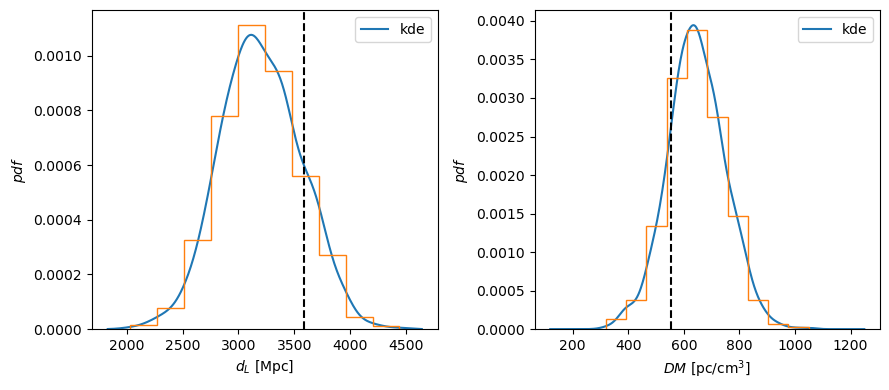

In [16]:
dl_array=np.linspace(np.min(dL_gaussian)-200, np.max(dL_gaussian)+200, 500)
DM_array=np.linspace(np.min(DM_gaussian)-200, np.max(DM_gaussian)+200, 500)

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(dl_array, GW_dL_kde(dl_array), label='kde')
ax1.hist(dL_gaussian, density=True, histtype='step')
ax1.axvline(x=dL_centre, ls='--', c='black')
ax1.set_xlabel(r'$d_L$ [Mpc]')
ax1.set_ylabel(r'$pdf$')
ax1.legend()


ax2.plot(DM_array, FRB_DM_kde(DM_array), label='kde')
ax2.hist(DM_gaussian, density=True, histtype='step')
ax2.axvline(x=DM_centre, ls='--', c='black')
ax2.set_xlabel(r'$DM$ [pc/cm$^3$]')
ax2.set_ylabel(r'$pdf$')
ax2.legend()

plt.tight_layout()
plt.show()

We now create a redshift range capable of covering the full range of $d_L$ and ${\rm DM}$.

In [17]:
## Redshift range
z_array=np.linspace(0.2, 1.2, 200) #JM: Why 1.2 here, not 2.0?

## Luminosity distance and DM range for fiducial cosmology (for visualisation purposes)
lum_distance = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

DM_distance = []
for z_val in z_array:
    DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=HUBBLE))
    
DM_distance = np.array(DM_distance)

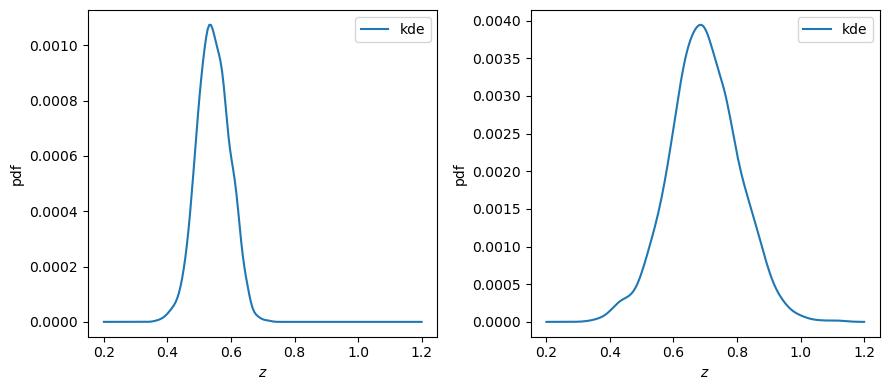

In [18]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_array, GW_dL_kde(lum_distance), label='kde')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'pdf')
ax1.legend()


ax2.plot(z_array, FRB_DM_kde(DM_distance), label='kde')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'pdf')
ax2.legend()

plt.tight_layout()
plt.show()

**$H_0$ inference, assuming a fixed $\Omega_m$**. 

For a given $H_0$, we produce a distance and DM range and weight compared to our observed pdfs for $d_L$ and ${\rm DM}$. Since these two observations were made independently, we multiply their LHDs.

In [19]:
H0_array = np.linspace(20,120, 200)
posterior_normed = np.zeros_like(H0_array)

for i, H0 in enumerate(H0_array):
    lum_distance = FlatLambdaCDM(H0=H0, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

    DM_distance = []
    for z_val in z_array:
        DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=H0))

    DM_distance = np.array(DM_distance)
    
    # Integrate out the redshift dependence
    posterior_normed[i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)

## Normalise posterior
posterior_normed/=np.trapz(posterior_normed, H0_array)

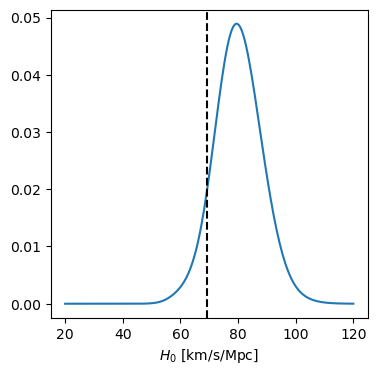

In [20]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)

ax1.plot(H0_array, posterior_normed, label='kde')
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')

plt.show()

### **Multiple events**

Extend the analysis above to multiple events

<div class="alert alert-block alert-danger">
<b>NB:</b> Under progress!
</div>

In [21]:
## Random choice of redshifts
zs_centre = np.random.choice(np.linspace(0.5, 1.5, 20), size=5)

dL_centres = cosmo_fid.luminosity_distance(zs_centre).value

DM_centres = []
for z_val in zs_centre:
    DM_centres.append(dispersion_measure(z_val, OMEGA_MATTER, HUBBLE))

In [22]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centres

## Choice of observed DM
sigma_DM = 105

dL_obs_centres = np.zeros_like(zs_centre)
DM_obs_centres = np.zeros_like(zs_centre)

for idx, dL in enumerate(dL_centres):
    dL_obs_centres[idx] = np.random.normal(dL, sigma_dL[idx])
    DM_obs_centres[idx] = np.random.normal(DM_centres[idx], sigma_DM)

In [25]:
H0_array = np.linspace(20,120, 200)
posterior_normed = np.zeros_like(H0_array)
z_array=np.linspace(0.2, 2.0, 200) # I changed the maximum to 2 here
posterior_normed = np.zeros_like(H0_array)
posterior_normed_all = np.zeros_like(H0_array)+1

for idx, dL in enumerate(dL_obs_centres):
    dL_gaussian = np.random.normal(dL, sigma_dL[idx], 1000)
    DM_gaussian = np.random.normal(DM_obs_centres[idx], sigma_DM, 1000)
    
    ## Fitting KDEs around the observed events
    GW_dL_kde = gaussian_kde(dL_gaussian)
    FRB_DM_kde = gaussian_kde(DM_gaussian)
    
    for i, H0 in enumerate(H0_array):
        lum_distance=FlatLambdaCDM(H0=H0, Om0=OMEGA_MATTER).luminosity_distance(z_array).value
        
        DM_distance = []
        for z_val in z_array:
            DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=H0))

        DM_distance = np.array(DM_distance)
        
        posterior_normed[i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)
        
    posterior_normed/=np.trapz(posterior_normed, H0_array)
    
    posterior_normed_all=posterior_normed_all*posterior_normed

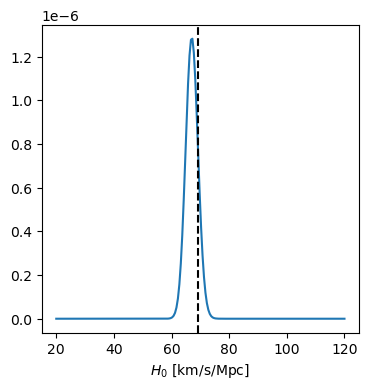

In [26]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)

ax1.plot(H0_array, posterior_normed_all, label='kde')
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')

plt.show()